Just starting with small example of merging data after creating  2 tables ourselves and later joining/merging it

In [2]:
import pandas as pd


In [3]:
df_jobs = {
    "job_id": [0,1,2,3,4],
    "job_title": ["Data Scientist", "Software Engineer ", "Product Manager", "Marketing Director", "HR Manager"],
    "company_name": ["Google", "Microsoft", "Apple", "Nike", "Starbucks"],
    "job_location": ["Mountain View, CA", "Remond, WA", "Cupertino, CA", "Beacerton, OR", "Seattle, WA"]
    
}

df_jobs = pd.DataFrame(df_jobs)

print(df_jobs)

   job_id           job_title company_name       job_location
0       0      Data Scientist       Google  Mountain View, CA
1       1  Software Engineer     Microsoft         Remond, WA
2       2     Product Manager        Apple      Cupertino, CA
3       3  Marketing Director         Nike      Beacerton, OR
4       4          HR Manager    Starbucks        Seattle, WA


In [4]:
df_companies={
    "company_name":["Google", "Microsoft", "Apple", "Nike", "Starbucks"],
    "industry":["Technology", "Technology", "Technology", "Apparel", "Food & Beverage"],
    "company_size": ["100,000+", "100,000+", "100,000+", "75000+", "340000+"]
}
df_companies=pd.DataFrame(df_companies)
df_companies
    


,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,75000+
4,Starbucks,Food & Beverage,340000+


In [5]:
df_jobs.merge(df_companies, on = "company_name")

,job_id,job_title,company_name,job_location,industry,company_size
0,0,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,1,Software Engineer,Microsoft,"Remond, WA",Technology,"100,000+"
2,2,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,3,Marketing Director,Nike,"Beacerton, OR",Apparel,75000+
4,4,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,340000+


In [23]:
from datasets import load_dataset
import matplotlib.pyplot as plt

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup Data /converting it into datetime format
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Pradi\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Sat Jun 13 17:04:48 2026).


In [7]:
df_US = df[df ['job_country'] == 'United States'].copy()
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

df_US_pivot.reset_index(inplace = True)
df_US_pivot['month_no'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month
df_US_pivot.sort_values('month_no', inplace = True)
df_US_pivot.set_index('job_posted_month', inplace=True) 
df_US_pivot.drop(columns='month_no', inplace=True)

In [8]:
dfII=pd.read_csv("https://lukeb.co/software_csv", index_col="job_posted_month")
merged_df=df_US_pivot.merge(dfII, on = "job_posted_month")


<Axes: xlabel='job_posted_month'>

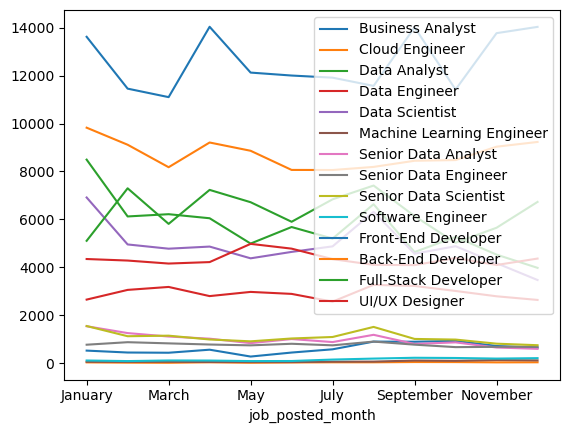

In [9]:
#merged_df['job_title_short'].value_counts().head(5)
merged_df.plot(kind='line')

In [13]:
top_5 = (merged_df
         .sum()
         .sort_values(ascending=False)
         .head(5)
         .index               #Get the index of the top 5
         .to_list())
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

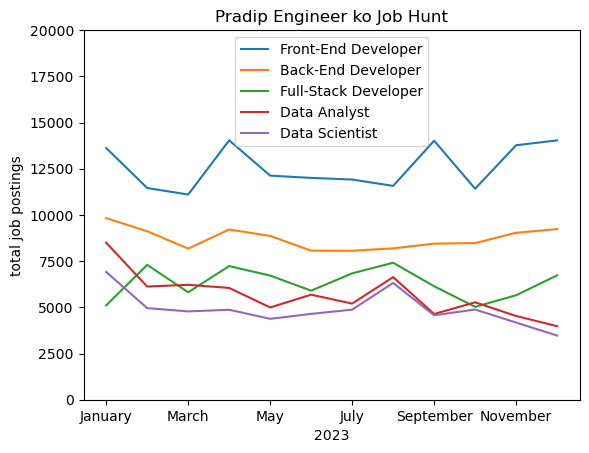

In [14]:
merged_df[top_5].plot(kind='line')
plt.title("Pradip Engineer ko Job Hunt")
plt.xlabel("2023")
plt.ylabel("total job postings")
plt.ylim(0, 20000)
plt.legend()
plt.show()

-Create a DataFrame df_us_jobs that contains only job postings in the United States.
-Then, create another DataFrame df_monthly_postings that counts the number of U.S. job postings for each month.
-Merge these two DataFrames on the job_posted_month column using a right join, and display the first 5 rows of the resulting DataFrame.

In [58]:
df_test = df.copy()
df_us_jobs = df_test[df_test['job_country']== 'United States']
df_us_jobs

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['..."
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}"
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN


In [66]:
df_us_jobs['job_posted_month'] = df_us_jobs['job_posted_date'].dt.to_period('M')
df_monthly_counts = df_us_jobs['job_posted_month'].value_counts().sort_index()
df_monthly_counts



job_posted_month
2023-01    22670
2023-02    18020
2023-03    17904
2023-04    17282
2023-05    15283
2023-06    16694
2023-07    16210
2023-08    21029
2023-09    16313
2023-10    16998
2023-11    14736
2023-12    13153
Freq: M, Name: count, dtype: int64

In [64]:
df['job_posted_month'] = df['job_posted_date'].dt.to_period('M')
df_us_jobs = df[df['job_country'] == 'United States']
df_us_jobs

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,2023-06
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",2023-07
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",2023-11
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",2023-03
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",2023-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN,2023-10
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",2023-07
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}",2023-04
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,2023-01


In [71]:
merged_df = pd.merge(df_us_jobs, df_monthly_postings, on='job_posted_month', how='right')
merged_df.head(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month,postings_count
0,Data Engineer,Data Engineer,"Fort Worth, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-25 13:24:01,False,False,United States,NaN,NaN,NaN,Programmers.io,"['sql', 'python']","{'programming': ['sql', 'python']}",2023-01,22670
1,Data Engineer,Data Engineer,"San Mateo, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-28 13:07:30,False,True,United States,NaN,NaN,NaN,Verkada,"['sql', 'python', 'aws', 'looker']","{'analyst_tools': ['looker'], 'cloud': ['aws']...",2023-01,22670
2,Business Analyst,Business Intelligence Intern,"Dallas, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 13:02:07,False,False,United States,NaN,NaN,NaN,Copart,"['r', 'python', 'sql', 'tableau', 'power bi']","{'analyst_tools': ['tableau', 'power bi'], 'pr...",2023-01,22670
3,Data Engineer,Data Engineer,"Cincinnati, OH",via SimplyHired,Full-time,False,"Texas, United States",2023-01-22 13:08:53,False,False,United States,NaN,NaN,NaN,Divisions Maintenance Group,"['sql', 'nosql', 'python', 'java', 'c++', 'sca...","{'databases': ['cassandra'], 'libraries': ['ha...",2023-01,22670
4,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,NaN,NaN,NaN,Citi,"['sql', 'python', 'unix', 'excel', 'jira']","{'analyst_tools': ['excel'], 'async': ['jira']...",2023-01,22670
5,Data Analyst,Marketing Data Analyst,"Garden City, NY",via WREG Jobs,Full-time,False,"New York, United States",2023-01-09 12:59:57,False,False,United States,NaN,NaN,NaN,Success Academy,"['sql', 'r', 'python', 'tableau']","{'analyst_tools': ['tableau'], 'programming': ...",2023-01,22670
6,Data Analyst,IT Business Lead Data Analyst - VP - Hybrid,"Atlantic Beach, FL",via ComputerJobs.com,Full-time,False,Georgia,2023-01-10 13:59:02,False,False,United States,year,133285.0,NaN,Citi,"['sql', 'word', 'excel', 'visio', 'powerpoint'...","{'analyst_tools': ['word', 'excel', 'visio', '...",2023-01,22670
7,Data Scientist,Data Scientist Technical Specialist,"Reston, VA",via LinkedIn,Full-time,False,Georgia,2023-01-26 13:49:37,False,False,United States,NaN,NaN,NaN,Peraton,['tableau'],{'analyst_tools': ['tableau']},2023-01,22670
8,Data Analyst,Data Analyst,"St Peters, MO",via Trabajo.org,Full-time,False,"Illinois, United States",2023-01-15 13:02:07,True,True,United States,NaN,NaN,NaN,"BizzyCar, Inc.",['tableau'],{'analyst_tools': ['tableau']},2023-01,22670
9,Data Engineer,"Staff Data Engineer, Real Time Analytics and E...","New York, NY",via WANE Jobs,Full-time,False,"Texas, United States",2023-01-30 13:08:41,False,True,United States,NaN,NaN,NaN,LTK (formerly rewardStyle & LIKEtoKNOW.it),"['python', 'r', 'scala', 'golang', 'sql', 'aws...","{'cloud': ['aws', 'redshift'], 'libraries': ['...",2023-01,22670
